# Machine Learning Experiment Number 6


**Name:** Om Milind Retharekar   
           
**Roll no.:** CS46

**Class:** BE CSE

**Batch:** CS03

#Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


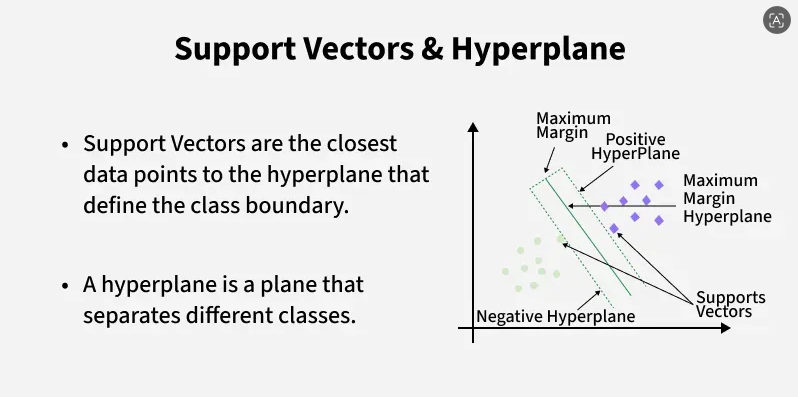
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [12]:
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

Saving Iris.csv to Iris (1).csv


# Task 2: Explore the Dataset

In [13]:
df.head()
df.info()
df.describe()
df['Species'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [14]:
df = df.drop('Id', axis=1)

X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [16]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate the accuracy of the SVM model
print("Accuracy:", accuracy_score(y_test, y_pred_linear))

# Generate the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))

# Generate the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_linear))

Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

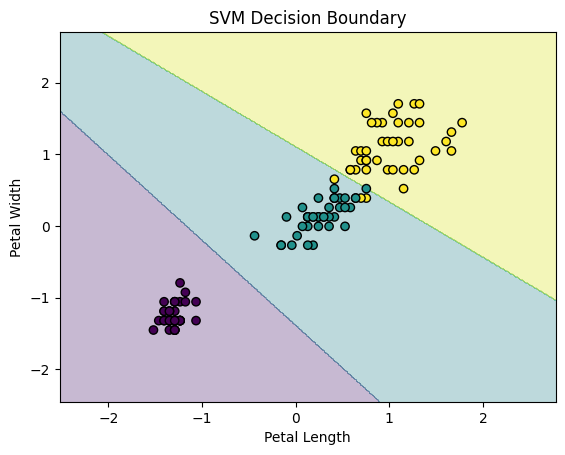

In [18]:
# Select Petal Length and Petal Width
X_2d = df[['PetalLengthCm', 'PetalWidthCm']]
y_2d = df['Species']

# Split the 2-D dataset
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

# Scale the selected features
scaler_2d = StandardScaler()
X_train_2d = scaler_2d.fit_transform(X_train_2d)
X_test_2d = scaler_2d.transform(X_test_2d)

# Train SVM using a linear kernel
svm_2d = SVC(kernel='linear')
svm_2d.fit(X_train_2d, y_train_2d)

# Encode class labels for visualization
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_2d)

# Create a mesh grid for plotting the decision boundary
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = label_encoder.transform(Z)
Z = Z.reshape(xx.shape)

# Plot the SVM decision boundary and data points
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train_encoded,
    edgecolors='k'
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('SVM Decision Boundary')
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

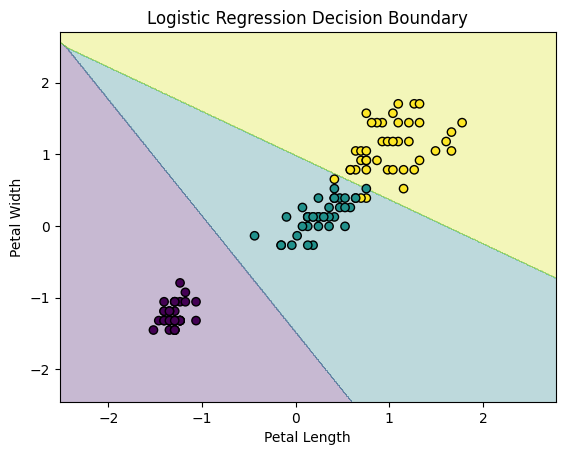

In [19]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression using the same two features
logistic_model = LogisticRegression()
logistic_model.fit(X_train_2d, y_train_2d)

# Create predictions for the decision boundary
Z_logistic = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_logistic = label_encoder.transform(Z_logistic)
Z_logistic = Z_logistic.reshape(xx.shape)

# Plot the Logistic Regression decision boundary
plt.contourf(xx, yy, Z_logistic, alpha=0.3)
plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train_encoded,
    edgecolors='k'
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Logistic Regression Decision Boundary')
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

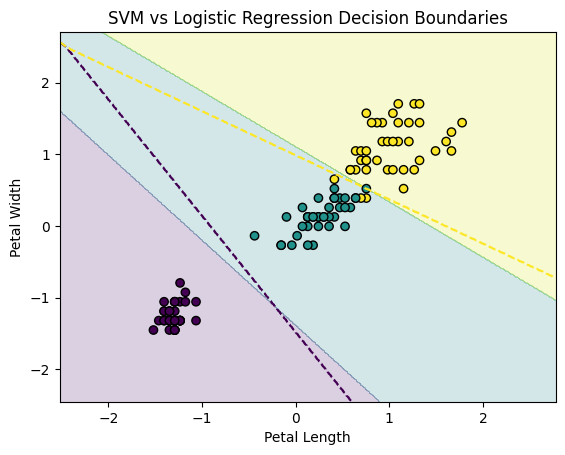

In [20]:
# Plot both decision boundaries on the same graph
plt.contourf(xx, yy, Z, alpha=0.2)
plt.contour(xx, yy, Z_logistic, levels=[0.5, 1.5], linestyles='--')

plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train_encoded,
    edgecolors='k'
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('SVM vs Logistic Regression Decision Boundaries')
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Compare Linear SVM performance
print("Linear SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))
print("Classification Report:")
print(classification_report(y_test, y_pred_linear))

# Compare Logistic Regression performance
y_pred_logistic = logistic_model.predict(X_test_2d)

print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test_2d, y_pred_logistic))
print("Confusion Matrix:")
print(confusion_matrix(y_test_2d, y_pred_logistic))
print("Classification Report:")
print(classification_report(y_test_2d, y_pred_logistic))

Linear SVM
Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Logistic Regression
Accuracy: 0.9333333333333333
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.